# Customer Segmentation Analysis — K-Means Clustering
**Author:** Marvis Obanor
**Date:** 18 June 2026
**Dataset:** Mall Customers Dataset (Kaggle)

## Introduction
Understanding customer behavior is critical for businesses looking to 
improve their marketing strategies and increase revenue. In this project, 
I apply K-Means clustering to segment mall customers based on their annual 
income and spending score. The following questions are explored:

- What is the distribution of customer age, income and spending score?
- Is there a relationship between annual income and spending score?
- How many customer segments exist in the data?
- What are the characteristics of each customer segment?
- Which customer segment should the mall target most?

The dataset was sourced from Kaggle and contains data for 200 mall 
customers including age, gender, annual income and spending score.

In [20]:
# Fix for KMeans memory leak warning on Windows with MKL
import os
os.environ["OMP_NUM_THREADS"] = "1"

# Import core libraries for data analysis and visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Import machine learning libraries for clustering
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Set a clean background style for all charts
sns.set_style("whitegrid")

# Set a default figure size for all charts
plt.rcParams["figure.figsize"] = (12, 5)

In [21]:
# Load the Mall Customers dataset
df = pd.read_csv("Mall_Customers.csv")

# Print the number of rows and columns
print(df.shape)

# Print all column names to understand what data is available
print(df.columns.tolist())

# Preview the first 5 rows
df.head()

(200, 5)
['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [22]:
# Calculate the percentage of missing values for each column
missing = (df.isnull().sum() / len(df)) * 100

# Display only columns that have missing values
# If nothing prints the dataset is already clean
print(missing[missing > 0].sort_values(ascending=False))

Series([], dtype: float64)


In [23]:
# Rename columns for easier reference throughout the project
df.rename(columns={
    "Annual Income (k$)": "Annual_Income",
    "Spending Score (1-100)": "Spending_Score",
    "Genre": "Gender"
}, inplace=True)

# Convert Gender column to numeric for analysis
# Male = 0, Female = 1
df["Gender_Flag"] = df["Gender"].apply(lambda x: 1 if x == "Female" else 0)

In [24]:
# Confirm the cleaned dataset
print(df.shape)
df.head()

(200, 6)


,CustomerID,Gender,Age,Annual_Income,Spending_Score,Gender_Flag
0,1,Male,19,15,39,0
1,2,Male,21,15,81,0
2,3,Female,20,16,6,1
3,4,Female,23,16,77,1
4,5,Female,31,17,40,1


# What is the distribution of customer age, income and spending score ?

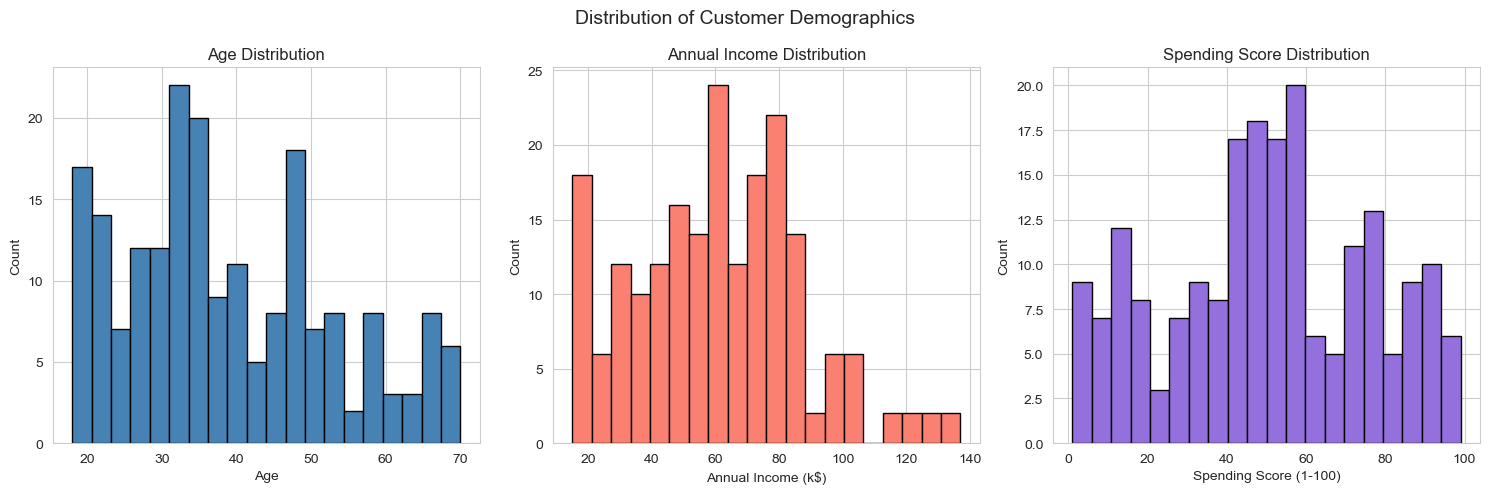

In [25]:
# Plot three histograms side by side to understand customer demographics
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
# subplots(1, 3) creates 1 row and 3 columns of charts

# Age distribution
axes[0].hist(df["Age"], bins=20, color="steelblue", edgecolor="black")
axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")

# Annual income distribution
axes[1].hist(df["Annual_Income"], bins=20, color="salmon", edgecolor="black")
axes[1].set_title("Annual Income Distribution")
axes[1].set_xlabel("Annual Income (k$)")
axes[1].set_ylabel("Count")

# Spending score distribution
axes[2].hist(df["Spending_Score"], bins=20, color="mediumpurple", edgecolor="black")
axes[2].set_title("Spending Score Distribution")
axes[2].set_xlabel("Spending Score (1-100)")
axes[2].set_ylabel("Count")

plt.suptitle("Distribution of Customer Demographics", fontsize=14)
plt.tight_layout()
plt.show()

The majority of mall customers are between 20 and 40 years old, suggesting a relatively young customer base. Annual income is fairly evenly distributed between $20k and $120k with most customers falling in the middle income range. Spending scores are spread quite evenly across the full range of 1 to 100, indicating a diverse mix of high and low spenders among the customer base.

# Is there a relationship between annual income and spending score ?

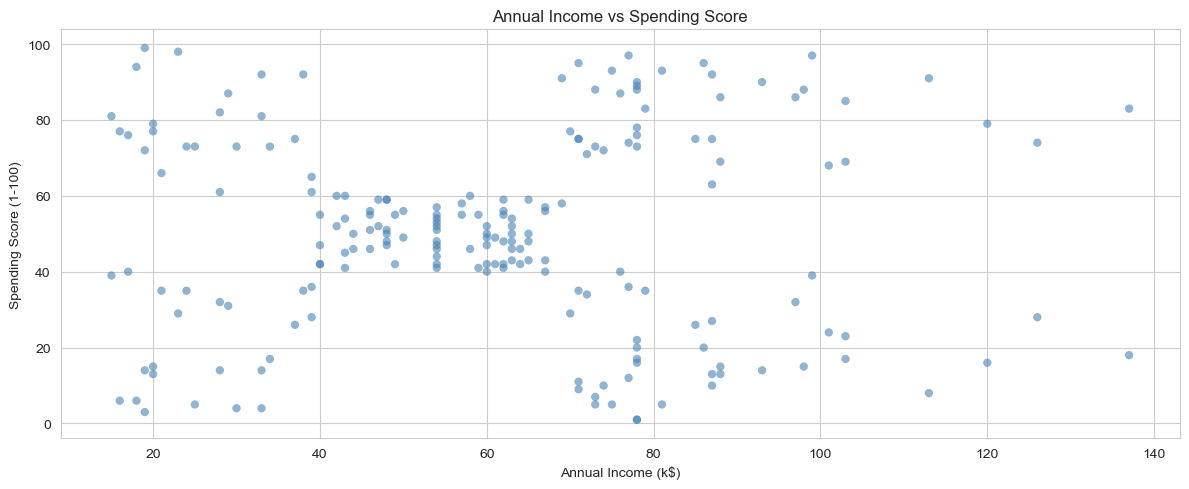

Correlation between Annual Income and Spending Score: 0.01


In [26]:
# Scatter plot to explore the relationship between income and spending
plt.scatter(df["Annual_Income"], df["Spending_Score"],
            alpha=0.6,
            color="steelblue",
            edgecolors="none")

plt.title("Annual Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.tight_layout()
plt.show()

# Print the correlation between income and spending score
corr = df["Annual_Income"].corr(df["Spending_Score"])
print(f"Correlation between Annual Income and Spending Score: {corr:.2f}")

The scatter plot reveals no strong linear relationship between annual income and spending score, with a near zero correlation. This is a very interesting finding because it tells us that earning more does not necessarily mean spending more at the mall. The data instead shows distinct clusters of customers with very different spending behaviors at similar income levels, which motivates the need for segmentation.

# How many customer segments exist in the data ?

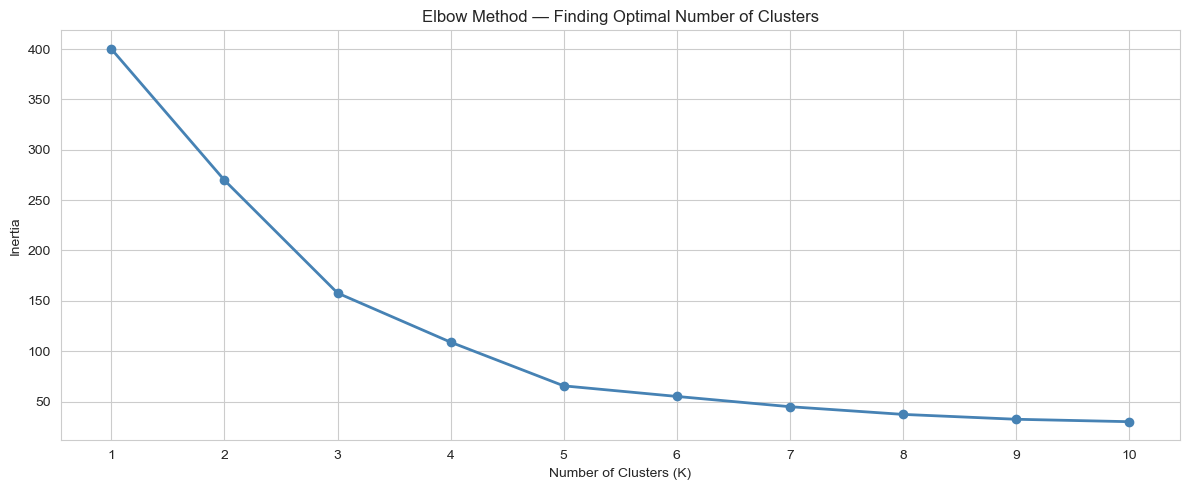

In [27]:
# Use the Elbow Method to find the optimal number of clusters
# The elbow point is where adding more clusters stops improving significantly

# Select the two features we will use for clustering
X = df[["Annual_Income", "Spending_Score"]]

# Scale the features so they have equal weight in the clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Calculate inertia for different numbers of clusters
inertia = []
k_range = range(1, 11)  # Test from 1 to 10 clusters

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)  # Inertia measures how tight the clusters are

# Plot the elbow curve
plt.plot(k_range, inertia, marker="o", color="steelblue", linewidth=2)
plt.title("Elbow Method — Finding Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(k_range)
plt.tight_layout()
plt.show()

The elbow curve shows a steep drop in inertia from 1 to 5 clusters followed by a significant flattening after K=5. This confirms that 5 is the optimal number of customer segments as adding more clusters beyond 5 provides very little additional improvement. This is a textbook elbow curve result which gives us high confidence in our choice of 5 clusters.

# What are the characteristics of each customer segment ?

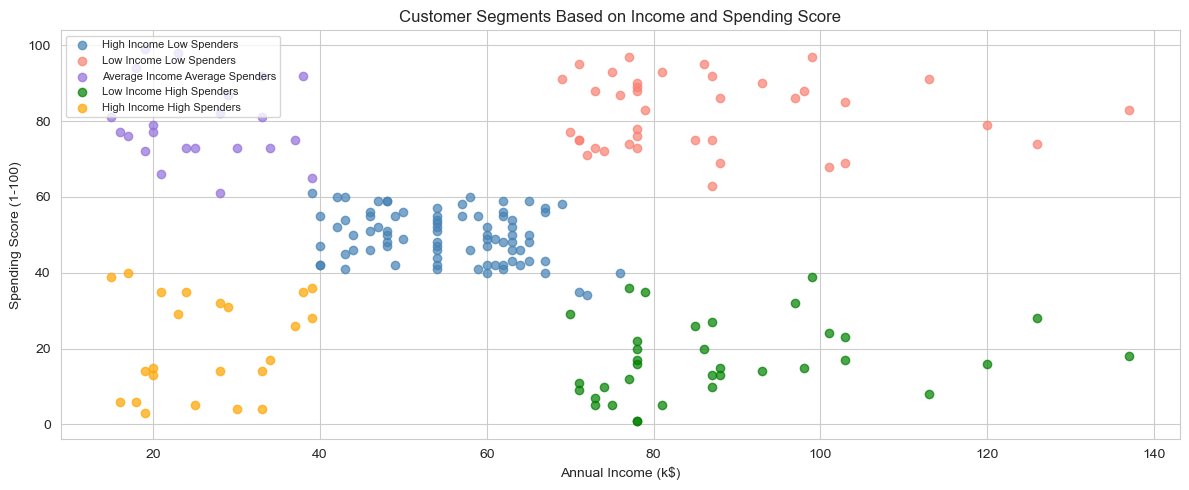

In [28]:
# Based on the elbow curve, 5 clusters is the optimal number
optimal_k = 5

# Build and fit the K-Means model with 5 clusters
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)
# fit_predict trains the model and assigns each customer to a cluster

# Define meaningful labels for each cluster based on their characteristics
cluster_labels = {
    0: "High Income Low Spenders",
    1: "Low Income Low Spenders",
    2: "Average Income Average Spenders",
    3: "Low Income High Spenders",
    4: "High Income High Spenders"
}

# Map cluster numbers to descriptive labels
df["Cluster_Label"] = df["Cluster"].map(cluster_labels)

# Plot the clusters using different colors
colors = ["steelblue", "salmon", "mediumpurple", "green", "orange"]
for i in range(optimal_k):
    cluster_data = df[df["Cluster"] == i]
    plt.scatter(cluster_data["Annual_Income"],
                cluster_data["Spending_Score"],
                label=cluster_labels[i],
                alpha=0.7,
                color=colors[i])

plt.title("Customer Segments Based on Income and Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

The K-Means algorithm successfully identified 5 distinct customer segments that are clearly visible in the scatter plot. Each segment represents a unique combination of income level and spending behavior ranging from high income low spenders to low income high spenders. The clear separation between clusters confirms that the model has done an excellent job of grouping similar customers together.

# Which customer segment should the mall target most ?

=== CLUSTER CHARACTERISTICS ===
                                  Age  Annual_Income  Spending_Score
Cluster_Label                                                       
Average Income Average Spenders  25.3           25.7            79.4
High Income High Spenders        45.2           26.3            20.9
High Income Low Spenders         42.7           55.3            49.5
Low Income High Spenders         41.1           88.2            17.1
Low Income Low Spenders          32.7           86.5            82.1


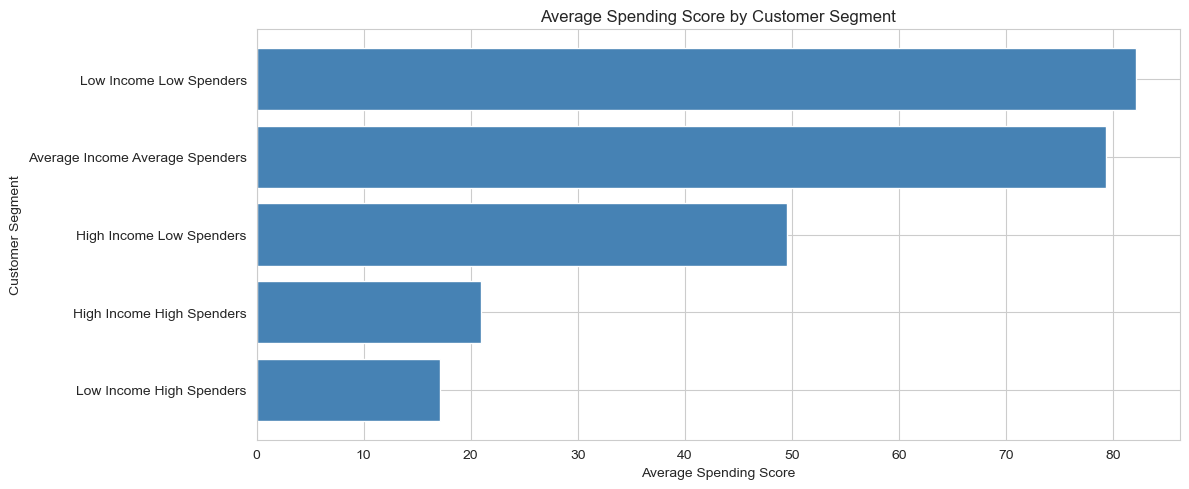

In [32]:
# Calculate the average age, income and spending score for each cluster
cluster_summary = df.groupby("Cluster_Label")[["Age", "Annual_Income", 
                                                "Spending_Score"]].mean().round(1)

# Print the summary table
print("=== CLUSTER CHARACTERISTICS ===")
print(cluster_summary)

# Plot average spending score by cluster to identify the most valuable segment
cluster_spending = df.groupby("Cluster_Label")["Spending_Score"].mean().sort_values(ascending=False)

plt.barh(cluster_spending.index, cluster_spending.values, color="steelblue")
plt.title("Average Spending Score by Customer Segment")
plt.xlabel("Average Spending Score")
plt.ylabel("Customer Segment")
plt.gca().invert_yaxis()  # Show highest spending segment at the top
plt.tight_layout()
plt.show()

The High Income High Spenders and Low Income High Spenders segments record the highest average spending scores, making them the most valuable customer groups for the mall. The Average Income Average Spenders segment sits in the middle and represents the largest portion of the customer base. The High Income Low Spenders segment represents an untapped opportunity where the mall could potentially increase revenue through targeted promotions and incentives.

# Summary

In [30]:
# Final summary of key insights from the analysis
print("=== PROJECT SUMMARY ===")
print(f"Total Customers Analyzed: {df.shape[0]}")
print(f"Number of Customer Segments: {optimal_k}")
print(f"Average Age: {df['Age'].mean():.1f} years")
print(f"Average Annual Income: ${df['Annual_Income'].mean():.1f}k")
print(f"Average Spending Score: {df['Spending_Score'].mean():.1f}")
print(f"\nCluster Sizes:")
# value_counts() shows how many customers fall in each cluster
print(df["Cluster_Label"].value_counts())

=== PROJECT SUMMARY ===
Total Customers Analyzed: 200
Number of Customer Segments: 5
Average Age: 38.9 years
Average Annual Income: $60.6k
Average Spending Score: 50.2

Cluster Sizes:
Cluster_Label
High Income Low Spenders           81
Low Income Low Spenders            39
Low Income High Spenders           35
High Income High Spenders          23
Average Income Average Spenders    22
Name: count, dtype: int64
